### Import required libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os
import math
import warnings
import numpy as np
warnings.filterwarnings('ignore')


import scimap

### Set color palette for visualzation

In [26]:
colors_palette = [
'#ebac23', 
'#b80058', #lipstick 0,140,249 
'#008cf9', #azure 0,110,0 
'#006e00', #green 0,187,173 
'#00bbad', #caribbean 209,99,230 
'#d163e6', #lavender 178,69,2 cd 
'#b24502', #brown 255,146,135 
'#ff9287', #coral 89,84,214 
'#5954d6', #indigo 0,198,248 
'#00c6f8', #turquoise 135,133,0 
'#878500', #olive 0,167,108 
'#00a76c', #jade 189,189,189 
'#274d52', #plantation 199,162,166 
'#c7a2a6', #eunry 129,139,112 
'#818b70', #battleship 96,78,60 
'#604e3c', #kabul 140,159,183 
'#8c9fb7', #balihai 121,104,128 
'#796880', #rum,
'#56641a', #fernfrond 192,175,251 
'#c0affb', #perfume 230,161,118 
'#e6a176', #apricot 0,103,138 
'#00678a', #orient 152,68,100 
'#984464', #vinrouge 94,204,171 
'#5eccab', #downy
'#bdbdbd'] #gray

### Set file paths and directories

read merged data

In [27]:
root = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/'
data_dir = root+'data/'
out = root+'out_july2025_xenium/'

merged_dir = os.listdir(out + 'script09a_rctd_spatial_clustering/')

save_dir = out + 'script09b_spatial_clustering_figures_ol/'
os.makedirs(save_dir, exist_ok=True)


merged_adatas = os.listdir(out + 'script09a_rctd_spatial_clustering/')
merged_adatas = [x for x in merged_adatas if x.endswith('.h5ad')]
merged_adatas = [x for x in merged_adatas if 'subset' in x]

In [28]:
gbm = [sc.read_h5ad(out + 'script09a_rctd_spatial_clustering/' + file) for file in merged_adatas if 'gbm' in file][0]
ol = [sc.read_h5ad(out + 'script09a_rctd_spatial_clustering/' + file) for file in merged_adatas if 'ol' in file][0]
aa = [sc.read_h5ad(out + 'script09a_rctd_spatial_clustering/' + file) for file in merged_adatas if 'aa' in file][0]

In [29]:
data = ol
data

AnnData object with n_obs × n_vars = 49958 × 201
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'core_id',

In [30]:
target_res = 'leiden_harmony_r0.4'
sample_name = 'ol'

In [31]:
df = data.obs[['core_id', 'Region', 'rctd_cell_type', target_res]]
df

,core_id,Region,rctd_cell_type,leiden_harmony_r0.4
lckhpdfl-1-0,Oligo4_Core,Core,NaN,1
anokdogp-1-0,Oligo4_Core,Core,NaN,1
lckiokin-1-0,Oligo4_Core,Core,NaN,1
lckhmneb-1-0,Oligo4_Core,Core,NaN,4
mefpkiic-1-0,Oligo4_Core,Core,NaN,1
...,...,...,...,...
ljeclkig-1-11,OligoGr3_Core,Core,NaN,0
mhofneea-1-11,OligoGr3_Core,Core,NaN,0
aocbbjgn-1-11,OligoGr3_Core,Core,NaN,0
liedplgm-1-11,OligoGr3_Core,Core,NaN,0


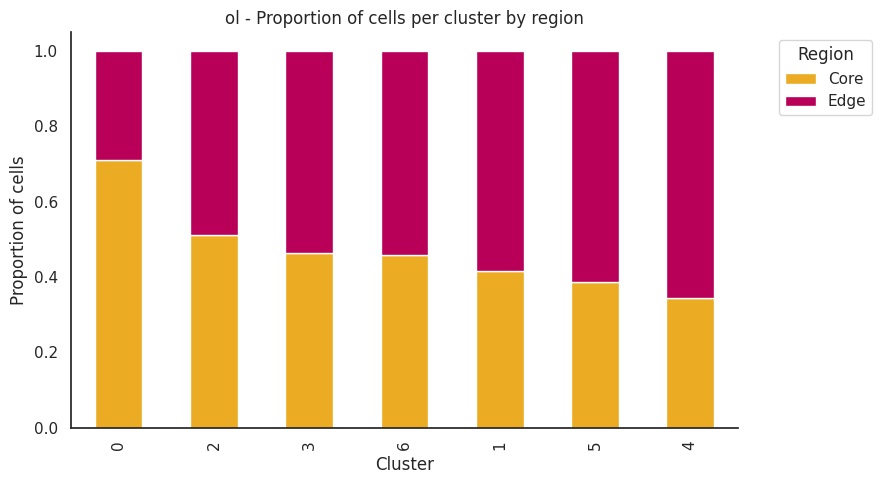

In [32]:
### plot proportions of cells types in each cluster by region
df['Region'] = df['Region'].astype('category')
df['rctd_cell_type'] = df['rctd_cell_type'].astype('category')
df[target_res] = df[target_res].astype('category')


# Count cells per (cluster, region)
df_counts = df.groupby([target_res, 'Region']).size().unstack().fillna(0)
df_counts = df_counts.sort_values(by='Core', ascending=False)

# Normalize to proportions (sum per cluster)
df_proportions = df_counts.div(df_counts.sum(axis=1), axis=0)
df_proportions = df_proportions.sort_values(by='Core', ascending=False)


# Plot
plt.figure(figsize=(9, 5))
df_proportions.plot(kind='bar', stacked=True, color=colors_palette, ax=plt.gca())
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Proportion of cells')
plt.xlabel('Cluster')
plt.title(f'{sample_name} - Proportion of cells per cluster by region')

### remove the top and right spines from plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(save_dir + f'{sample_name}_proportion_cells_per_cluster_by_region.png', dpi=300)

In [33]:
df_core = df[df['Region']=='Core']
df_edge = df[df['Region']=='Edge']

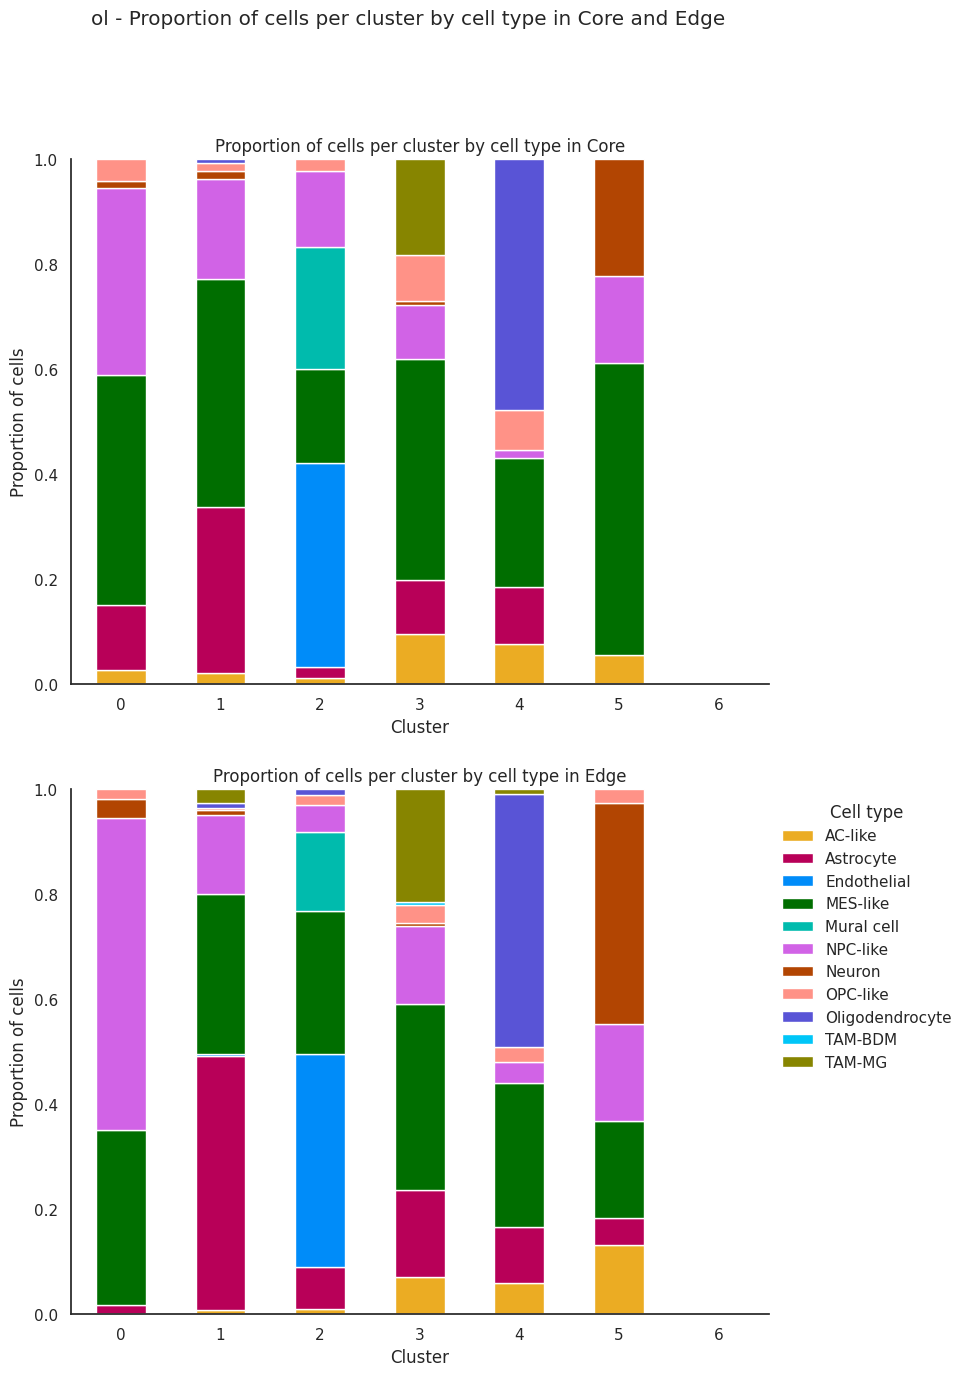

In [34]:
### plot proportions of cells types in each cluster by region
df_core_counts = df_core.groupby([target_res, 'rctd_cell_type']).size().unstack().fillna(0)
df_core_proportions = df_core_counts.div(df_core_counts.sum(axis=1), axis=0)


df_edge_counts = df_edge.groupby([target_res, 'rctd_cell_type']).size().unstack().fillna(0)
df_edge_proportions = df_edge_counts.div(df_edge_counts.sum(axis=1), axis=0)

fig, axs = plt.subplots(2, 1, figsize=(9, 15))
fig.suptitle(f'{sample_name} - Proportion of cells per cluster by cell type in Core and Edge')

df_core_proportions.plot(kind='bar', stacked=True, color=colors_palette, ax=axs[0])
axs[0].legend_.remove()
axs[0].set_ylabel('Proportion of cells')
axs[0].set_xlabel('Cluster')
axs[0].set_title('Proportion of cells per cluster by cell type in Core')
axs[0].set_xticklabels(df_core_proportions.index, rotation=0)
axs[0].set_ylim(0, 1)


df_edge_proportions.plot(kind='bar', stacked=True, color=colors_palette, ax=axs[1])
axs[1].legend(title='Cell type', bbox_to_anchor=(1, 1), frameon=False)
axs[1].set_ylabel('Proportion of cells')
axs[1].set_xlabel('Cluster')
axs[1].set_title('Proportion of cells per cluster by cell type in Edge')
axs[1].set_xticklabels(df_edge_proportions.index, rotation=0)
axs[1].set_ylim(0, 1)

sns.despine()
plt.savefig(save_dir + f'{sample_name}_proportion_cells_per_cluster_by_cell_type.png', dpi=300)

### Spatial interaction mapping

Spatial interaction analysis between cell types

In [35]:
data_core = data[data.obs['Region']=='Core']
data_edge = data[data.obs['Region']=='Edge']

Using 10 phenotypes across both regions: ['AC-like', 'Astrocyte', 'Endothelial', 'MES-like', 'Mural cell', 'NPC-like', 'Neuron', 'OPC-like', 'Oligodendrocyte', 'TAM-MG']
Core n_cats= 10
Edge n_cats= 10
Processing Image: ['Core']
Categories (1, object): ['Core']
Identifying the 50 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 1000 permutations


Consolidating the permutation results
Processing Image: ['Edge']
Categories (1, object): ['Edge']
Identifying the 50 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 1000 permutations
Consolidating the permutation results


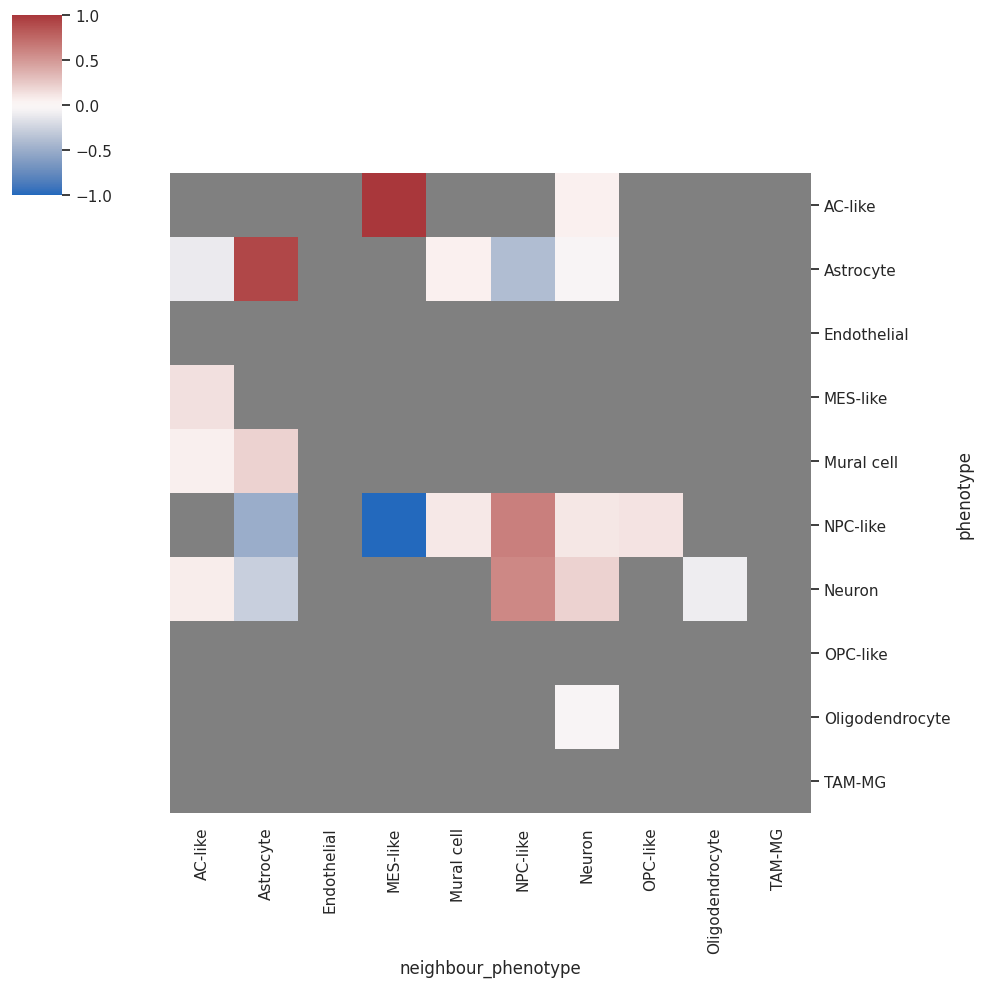

In [36]:
import numpy as np
import pandas as pd
import scimap as sm

adata = data.copy()                 # your AnnData
ct = "rctd_cell_type"
k = 50
min_cells = 5

# 1) clean + pick phenotypes present with enough cells in BOTH regions
adata = adata[~adata.obs[ct].isna()].copy()
adata.obs[ct] = adata.obs[ct].astype("category")

present = (adata.obs
           .groupby("Region")[ct]
           .value_counts()
           .unstack(fill_value=0))

common = present.columns[(present >= min_cells).all()]
print(f"Using {len(common)} phenotypes across both regions:", list(common))

adata_f = adata[adata.obs[ct].isin(common)].copy()
adata_f.obs[ct] = adata_f.obs[ct].cat.remove_unused_categories()

# sanity: same number of categories per region
for r in adata_f.obs["Region"].unique():
    n = adata_f[adata_f.obs["Region"] == r].obs[ct].nunique()
    print(r, "n_cats=", n)

# 2) run interaction (NOTE: subset=None)
sm.tl.spatial_interaction(
    adata_f,
    x_coordinate="x_centroid",
    y_coordinate="y_centroid",
    z_coordinate=None,
    phenotype=ct,
    method="knn",
    knn=k,
    permutation=1000,
    imageid="Region",
    subset=None,                  # <-- important: don't pass phenotype list here
    pval_method="zscore",
    verbose=True,
    label="spatial_interaction_region",
)

# plot
sm.pl.spatial_interaction(adata_f, "spatial_interaction_region")


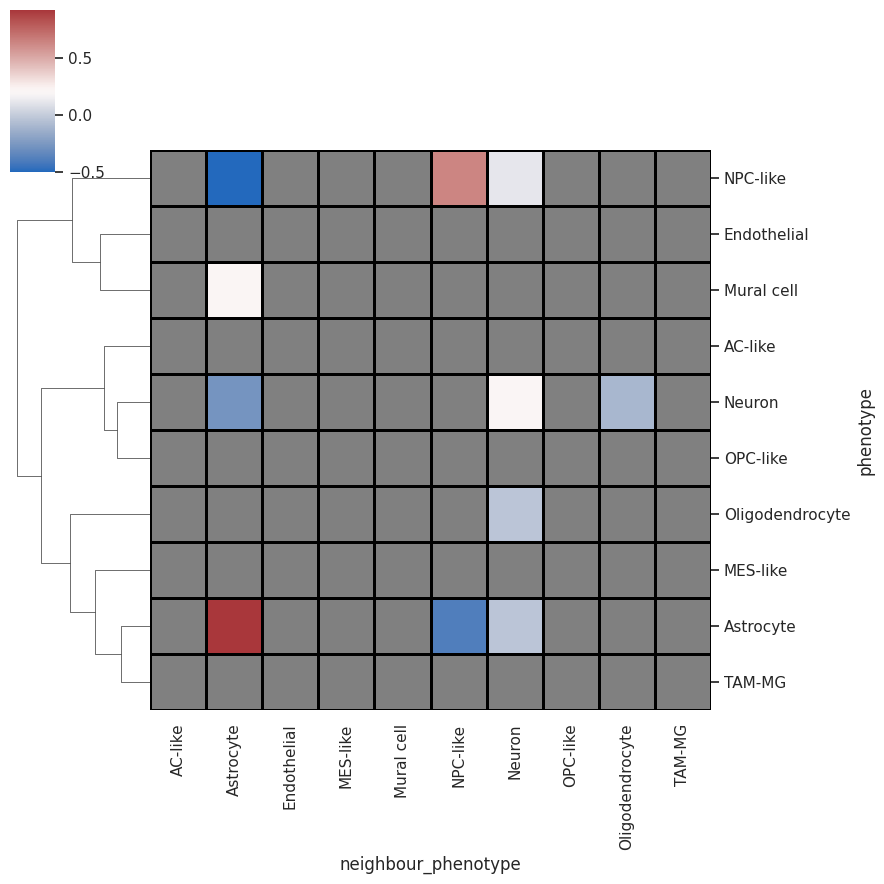

<Figure size 640x480 with 0 Axes>

In [37]:
scimap.pl.spatial_interaction(adata_f, 
                          spatial_interaction='spatial_interaction_region',
                          yticklabels=True, 
                          figsize=(9,9), 
                          row_cluster=True,
                          summarize_plot=True,
                          p_val=0.001,
                          cmap='vlag',
                          linewidths=0.75, linecolor='black')

plt.savefig(save_dir+ f'/script09b_fig2_{sample_name}_spatial_interaction_region_summarized.pdf', bbox_inches='tight')

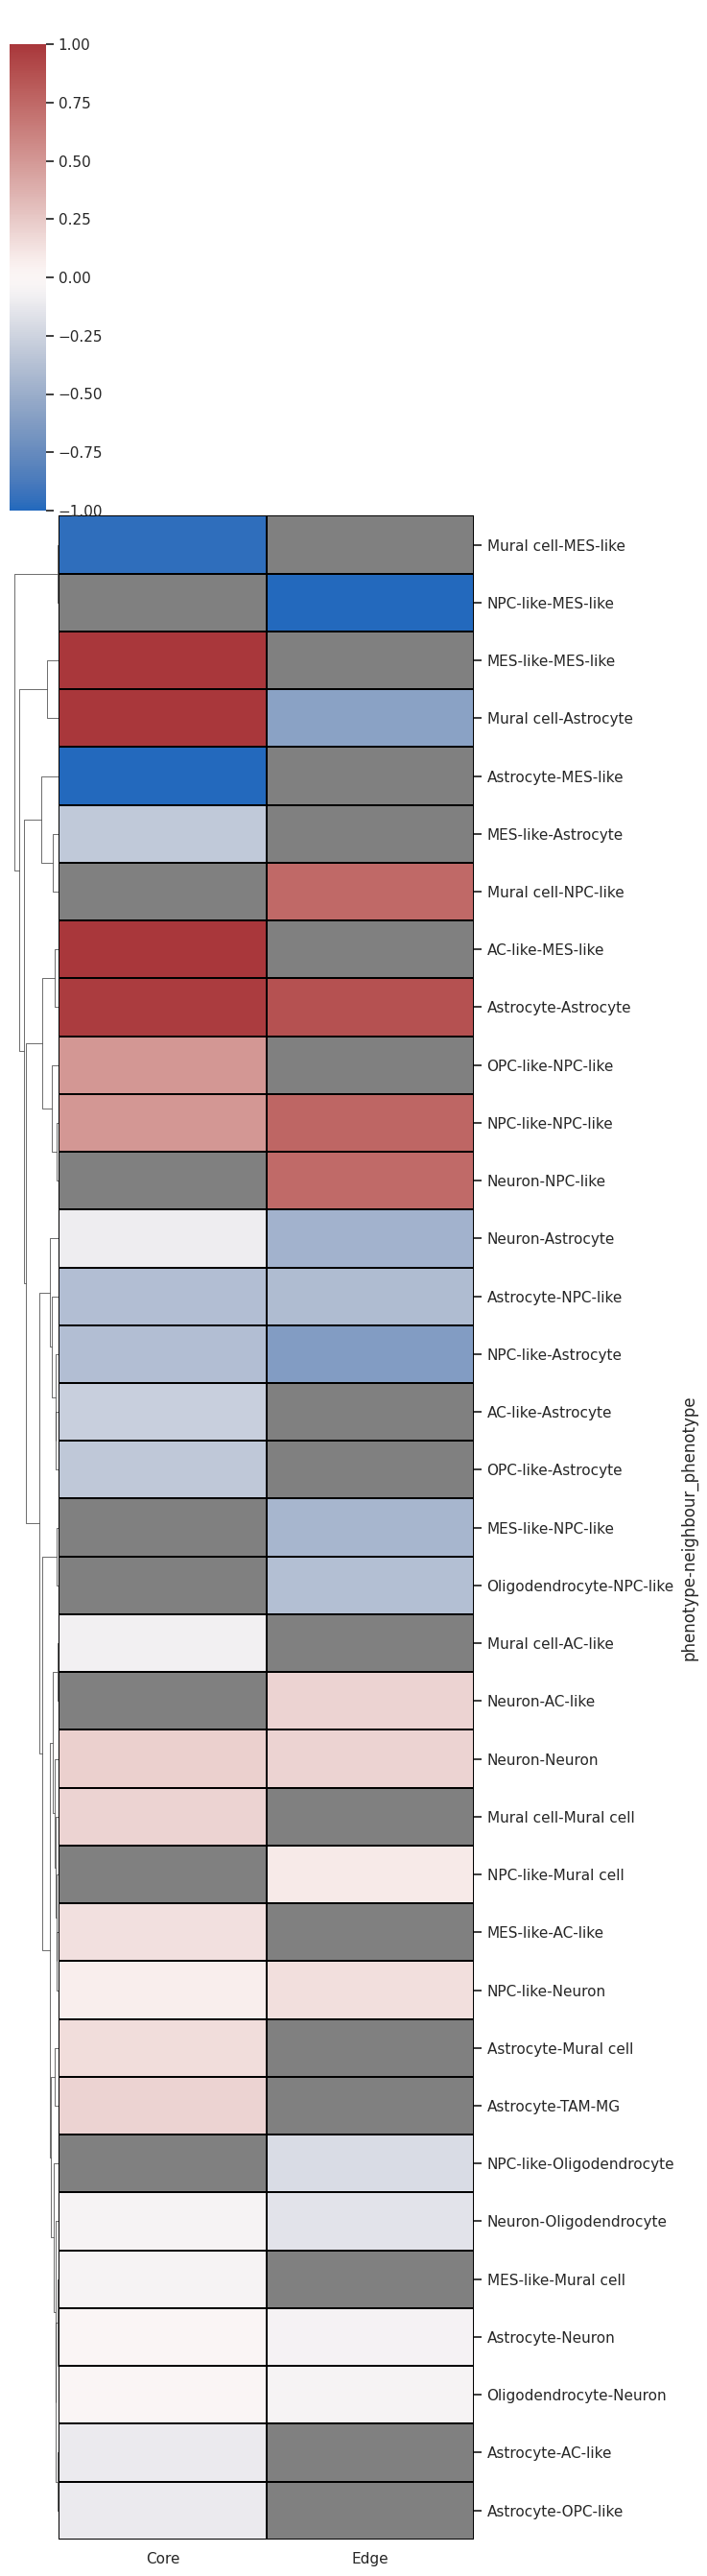

In [38]:
scimap.pl.spatial_interaction(adata_f, 
                          spatial_interaction='spatial_interaction_region',
                          yticklabels=True, 
                          figsize=(7.5,27), 
                          row_cluster=True,
                          summarize_plot=False,
                          linewidths=0.01, 
                          p_val=0.001,
                          #binary_view=True,
                          #pval_method = 'zscore',
                          linecolor='black',
                          dendrogram_ratio=(.1, .2))

#plt.savefig(save_dir+ f'/script09b_fig2_{sample_name}_spatial_interaction_region_summarized.pdf', bbox_inches='tight')pval_method

In [39]:
tumor_types = data.obs['rctd_cell_type'].unique().tolist()
tumor_types = ['RG',
 #'Mural cell',
 'Astrocyte',
 'OPC-like',
 'AC-like',
 'Endothelial',
# 'Mono',
 'NPC-like',
# 'TAM-BDM',
# 'DC',
 'MES-like',
# 'TAM-MG',
# 'CD4/CD8',
 'OPC',
# 'Plasma B',
# 'Neutrophil',
# 'B cell',
# 'Mast',
 'Neuron',
# 'NK',
 'Oligodendrocyte'
 ]

In [40]:
### subset data by keeping only tumor types

data_ttypes = data[data.obs['rctd_cell_type'].isin(tumor_types)]
data_ttypes

View of AnnData object with n_obs × n_vars = 1102 × 201
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'co

In [41]:
scimap.tl.spatial_interaction(data_ttypes, 
                    x_coordinate='x_centroid', 
                    y_coordinate='y_centroid', 
                    z_coordinate=None, 
                    phenotype='rctd_cell_type', 
                    method='knn', 
                    knn=50, 
                    permutation=500, 
                    imageid='Region', 
                    subset=None, 
                    pval_method='zscore', 
                    verbose=True, 
                    label='spatial_interaction_region')

Processing Image: ['Core']
Categories (1, object): ['Core']
Identifying the 50 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 500 permutations


Consolidating the permutation results
Processing Image: ['Edge']
Categories (1, object): ['Edge']
Identifying the 50 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 500 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 1102 × 201
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'core_id', 

In [42]:
data_ttypes.uns['spatial_interaction_region']


,phenotype,neighbour_phenotype,Core,pvalue_Core,Edge,pvalue_Edge
0,AC-like,AC-like,-0.108527,6.540296e-01,0.145455,0.033916
1,AC-like,Astrocyte,-0.263566,1.009442e-08,-0.616162,0.066521
2,AC-like,Endothelial,0.172481,7.274012e-01,-0.137374,0.211798
3,AC-like,MES-like,1.000000,9.992909e-04,1.000000,0.006316
4,AC-like,NPC-like,0.397287,3.027429e-01,-0.375758,0.006112
...,...,...,...,...,...,...
59,Oligodendrocyte,MES-like,1.000000,8.922878e-01,1.000000,0.128718
60,Oligodendrocyte,NPC-like,0.413183,9.246243e-01,-0.381271,0.000002
61,Oligodendrocyte,Neuron,-0.014469,2.206393e-05,-0.056856,0.000219
62,Oligodendrocyte,OPC-like,-0.115756,6.056983e-01,-0.054627,0.313406


In [43]:
df = data_ttypes.uns['spatial_interaction_region']

df_subset = df[(df['pvalue_Core'] < 0.001) | (df['pvalue_Edge'] < 0.001)]
df_subset = df_subset[(df_subset['Core'] > 0.0001) | (df_subset['Edge'] > 0.0001)]
#df_subset = df[(df['Core'] > 0.24) | (df['Edge'] > 0.24)]


#df_subset = df_subset[df_subset['pvalue_Edge'] < 0.01]

df_subset['interaction'] = [x+' > '+y for x,y in zip(df_subset['phenotype'], df_subset['neighbour_phenotype'])]
df_subset

,phenotype,neighbour_phenotype,Core,pvalue_Core,Edge,pvalue_Edge,interaction
3,AC-like,MES-like,1.000000,9.992909e-04,1.000000,6.315753e-03,AC-like > MES-like
9,Astrocyte,Astrocyte,1.000000,1.367330e-146,0.860967,2.214679e-21,Astrocyte > Astrocyte
11,Astrocyte,MES-like,-0.965058,1.313142e-22,1.000000,7.287494e-01,Astrocyte > MES-like
24,MES-like,AC-like,0.136446,3.998581e-05,0.139483,1.210153e-02,MES-like > AC-like
25,MES-like,Astrocyte,-0.325509,1.039225e-34,0.759280,9.393960e-02,MES-like > Astrocyte
27,MES-like,MES-like,1.000000,7.651752e-14,1.000000,7.430418e-01,MES-like > MES-like
36,NPC-like,NPC-like,0.496042,5.052882e-06,0.758944,1.406259e-57,NPC-like > NPC-like
37,NPC-like,Neuron,0.071900,2.683640e-04,0.155425,2.060207e-15,NPC-like > Neuron
40,Neuron,AC-like,-0.048649,1.058827e-02,0.191304,7.664156e-04,Neuron > AC-like
43,Neuron,MES-like,1.000000,7.781993e-04,-1.000000,7.646701e-01,Neuron > MES-like


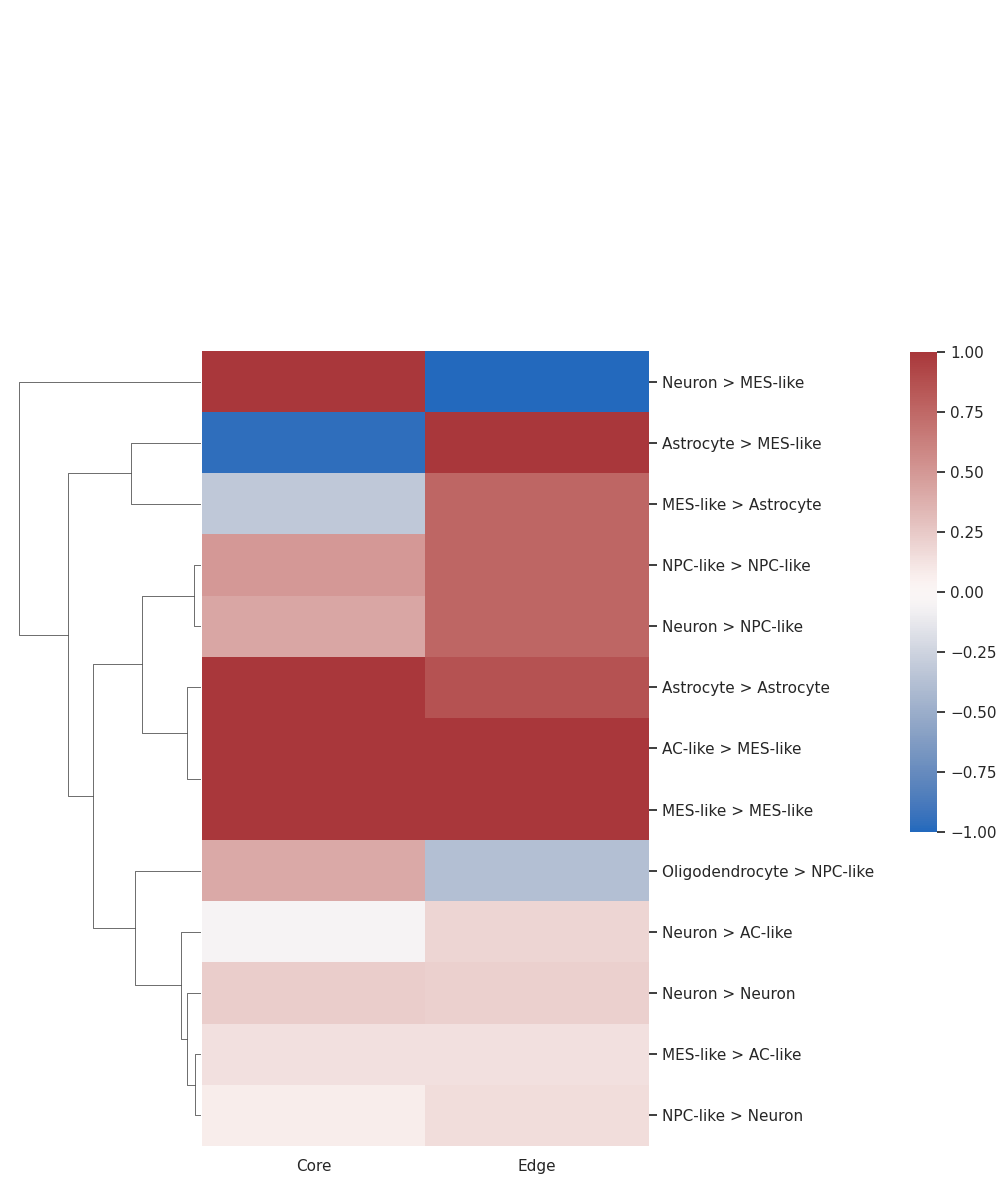

In [44]:
df_subset.index = df_subset['interaction'].tolist()

sns.clustermap(df_subset[['Core', 'Edge']],
                figsize=(9, 12), 
                cmap='vlag',
                row_cluster=True,
                col_cluster=False,
                cbar_pos=(1.02, 0.3, 0.03, 0.4),
                #cbar_kws={'label': 'p-value'},
                xticklabels=['Core', 'Edge'],
                #yticklabels=df_subset['interaction'].tolist(),
                dendrogram_ratio=(.3, .3),
                linewidths=0.001, 
                linecolor='black')

plt.savefig(save_dir+ f'/script09b_fig3_{sample_name}_spatial_interaction_region_tumor_types.pdf', bbox_inches='tight')

### Network Chord Diagrams


<Figure size 1400x1600 with 0 Axes>

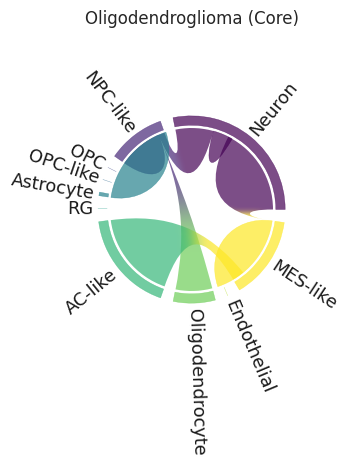

In [47]:
import pandas as pd
from mpl_chord_diagram import chord_diagram
import matplotlib.pyplot as plt

# Define custom order for labels
labels_ordered = [
    "Neuron","NPC-like","OPC","OPC-like",
    "Astrocyte","RG","AC-like",
    "Oligodendrocyte","Endothelial","MES-like"
]

# Create square matrix initialized with zeros
matrix = pd.DataFrame(0, index=labels_ordered, columns=labels_ordered)

# Fill matrix with interaction strengths
for _, row in df_subset.iterrows():
    src = row['phenotype']
    tgt = row['neighbour_phenotype']
    value = row['Core']  # or your chosen column
    if src in matrix.index and tgt in matrix.columns:
        matrix.loc[src, tgt] += value  # accumulate values

# Plot
plt.figure(figsize=(14, 16))

chord_diagram(
    matrix.values,
    names=labels_ordered,   # use the ordered labels!
    use_gradient=True,
    font_size=11,
    sort='distance',         # don’t reshuffle automatically
    wrap_labels=False,
    pad=8,                 # increase spacing
    rotate_names=True
)

plt.title('Oligodendroglioma (Core)', fontsize=12, pad=60)
plt.tight_layout()
plt.savefig(save_dir + f'/chord_spatial_interaction_Core_{sample_name}.jpg',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

<Figure size 1400x1600 with 0 Axes>

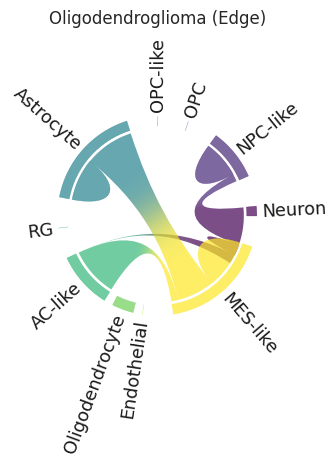

In [48]:
import pandas as pd
from mpl_chord_diagram import chord_diagram
import matplotlib.pyplot as plt

# Define custom order for labels
labels_ordered = [
    "Neuron","NPC-like","OPC","OPC-like",
    "Astrocyte","RG","AC-like",
    "Oligodendrocyte","Endothelial","MES-like"
]

# Create square matrix initialized with zeros
matrix = pd.DataFrame(0, index=labels_ordered, columns=labels_ordered)

# Fill matrix with interaction strengths
for _, row in df_subset.iterrows():
    src = row['phenotype']
    tgt = row['neighbour_phenotype']
    value = row['Edge']  # or your chosen column
    if src in matrix.index and tgt in matrix.columns:
        matrix.loc[src, tgt] += value  # accumulate values

# Plot
plt.figure(figsize=(14, 16))

chord_diagram(
    matrix.values,
    names=labels_ordered,   # use the ordered labels!
    use_gradient=True,
    font_size=11,
    sort='distance',         # don’t reshuffle automatically
    wrap_labels=False,
    pad=18,                 # increase spacing
    rotate_names=True
)

plt.title('Oligodendroglioma (Edge)', fontsize=12, pad=60)
plt.tight_layout()
plt.savefig(save_dir + f'/chord_spatial_interaction_Edge_{sample_name}.jpg',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()